# Plants and Signals

This notebook illustrates the construction of a lowpass filter as the solution of an ordinary differential equation, using SymPy.

In [1]:
using Plots

In [2]:
using SymPy

### 1. low and high frequency signals

Consider a low frequency signal which takes 1000 seconds to complete one cycle, and a high frequency signal which completes 1000 cycles in one second.

In [3]:
lowfreq(t) = sin(2*pi*t/1000)

lowfreq (generic function with 1 method)

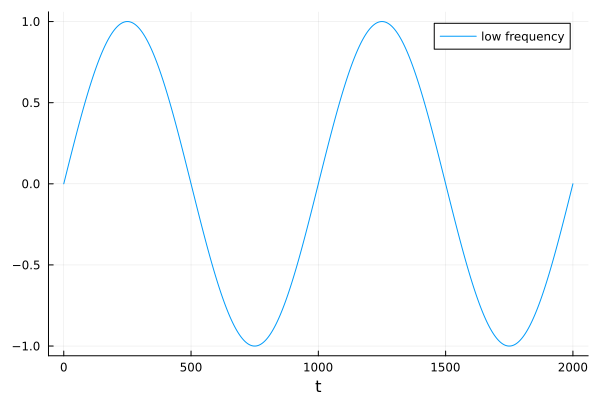

In [4]:
plot(0:0.1:2000, lowfreq, xlabel="t", label="low frequency")

In [5]:
# savefig("figlowfreqsignal.png")

In [6]:
highfreq(t) = sin(2*pi*t*1000)

highfreq (generic function with 1 method)

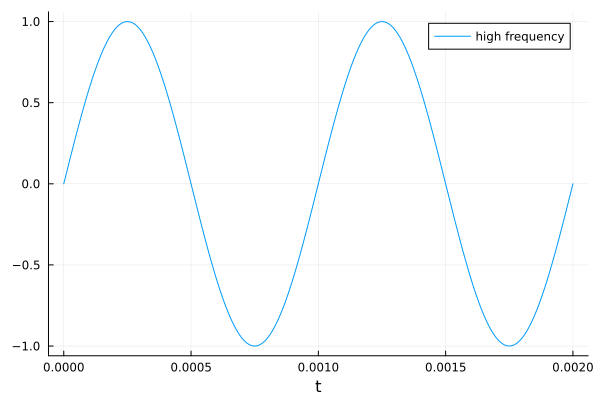

In [7]:
plot(0:0.01/1000:2/1000, highfreq, xlabel="t", label="high frequency")

In [8]:
# savefig("fighighfreqsignal.png")

### 2. a first order ordinary differential equation

Consider the following as the left hand side of an ordinary differential equation.

In [9]:
t = Sym("t")

t

In [10]:
y = SymFunction("y")

y

In [11]:
leftode = diff(y(t), t) + y(t)

       d       
y(t) + --(y(t))
       dt      

The initial condition is zero.

In [12]:
initcond = Dict(y(0) => 0)

Dict{Sym{PyCall.PyObject}, Int64} with 1 entry:
  y(0) => 0

The lowpass filter will take as right hand side the signal on input.

In [13]:
filtlow = Eq(leftode, lowfreq(t))

       d                                    
y(t) + --(y(t)) = sin(0.00628318530717959*t)
       dt                                   

In [14]:
outlow = dsolve(filtlow, ics=initcond)

                                                                              
y(t) = 0.99996052314088*sin(0.00628318530717959*t) - 0.00628293726675839*cos(0

                                             -t
.00628318530717959*t) + 0.00628293726675839*e  

Observe that the first term in the solution is almost identical to the ``lowfreq(t)``.  The second term has a small coefficient and the third term is decaying.

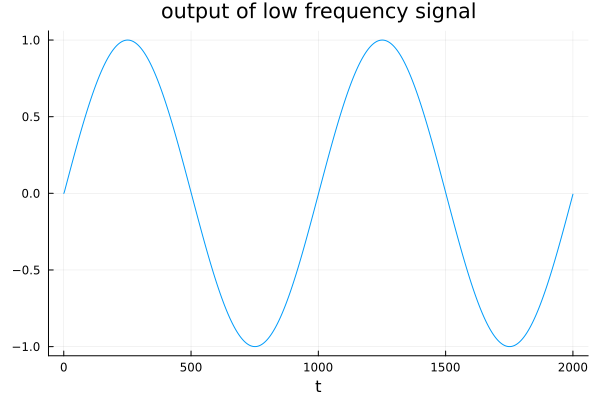

In [15]:
plot(0:0.1:2000, outlow.rhs(), xlabel="t", title="output of low frequency signal", label="")

In [16]:
# savefig("figlowfreqsignaloutput.png")

Let us now do the same for the high frequency signal.

In [17]:
filthigh = Eq(leftode, highfreq(t))

       d                                 
y(t) + --(y(t)) = sin(6283.18530717959*t)
       dt                                

In [18]:
outhigh = dsolve(filthigh, ics=initcond)

                                                                              
y(t) = 2.53302952689605e-8*sin(6283.18530717959*t) - 0.000159154939060454*cos(

                                            -t
6283.18530717959*t) + 0.000159154939060454*e  

Observe that the coefficient of the first term is really tiny and also the other coefficients, of the cosine, and of the decaying exponential, are small.

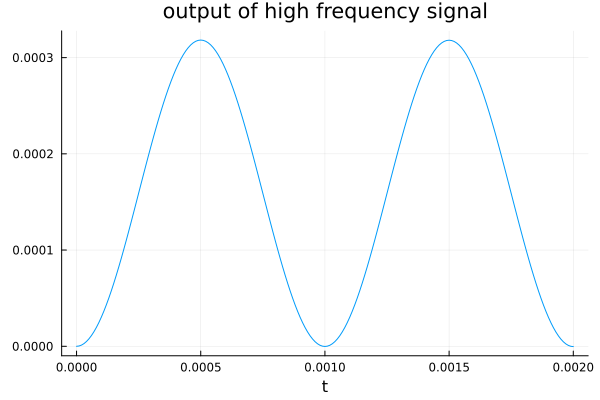

In [19]:
plot(0:0.01/1000:2/1000, outhigh.rhs(), xlabel="t", title="output of high frequency signal", label="")

In [20]:
# savefig("fighighfreqsignaloutput.png")